# QC partition v1

Validation pass over the cached partition v1 before declaring it frozen for training.

Checks:
1. **Cache integrity** - every case in `data_manifest/raw_cases_inventory.yaml` has the expected encounter files with the right shapes.
2A. **Vorticity-domain impact frame** - for every non-Baseline encounter, `argmax(|omega_z|)` near the airfoil over the impact window. Pass if all values fall inside `[25, 55]` AND the mean is within +/- 2 of frame 40. (Mode-at-40 is *not* expected: vorticity peaks pre-impact for strong gusts and post-impact for weak gusts; the bimodal distribution averages near 40 but no single mode lands there.)
2B. **Force-domain impact frame** - for every non-Baseline encounter, `argmax(|C_L - C_L_baseline|)` over the impact window. This tracks the kinematic LE-crossing more directly.
3. **Probe + force sanity plots** - Baseline (shedding only) vs `Gust_007` = G+4.0 (strong LE impact).

The loader smoke test from `SESSION_DATA_PREP.md` Step 6 lives in `src/data/episode_dataset.py` and is exercised separately.

In [1]:
%matplotlib inline
import json
import h5py
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path('/home/carlos/GUST-JEPA')
PREVENT_ROOT = Path('/home/carlos/PREVENT')

with open(REPO / 'configs/preprocessing.yaml') as f:
    config = yaml.safe_load(f)
with open(REPO / 'data_manifest/raw_cases_inventory.yaml') as f:
    inv = yaml.safe_load(f)
with open(REPO / 'configs/splits/split_v1.json') as f:
    split = json.load(f)

CACHE = PREVENT_ROOT / 'data/processed/vortex-jepa' / config['partition_target']
N_FRAMES = config['encounter']['frames_per_encounter']
IMPACT = config['encounter']['impact_frame_estimate']
WINDOW = config['encounter']['impact_window_frames']

print(f'Cache: {CACHE}')
print(f'Cases in inventory: {len(inv["cases"])}')
print(f'Frames per encounter: {N_FRAMES}')
print(f'Impact frame estimate: {IMPACT}, window: {WINDOW}')

Cache: /home/carlos/PREVENT/data/processed/vortex-jepa/v1
Cases in inventory: 43
Frames per encounter: 120
Impact frame estimate: 40, window: [25, 55]


## Check 1 - Cache integrity

In [2]:
expected = {k: tuple(config['outputs'][k]['shape']) for k in ['omega_z', 'p_wall', 'C_L', 'C_D']}

issues = []
total_expected = 0
total_actual = 0
for c in inv['cases']:
    cid = c['case_id']
    n_exp = c['n_encounters_full']
    total_expected += n_exp
    case_dir = CACHE / cid
    if not case_dir.exists():
        issues.append(f'{cid}: directory missing')
        continue
    encs = sorted(case_dir.glob('encounter_*.h5'))
    total_actual += len(encs)
    if len(encs) != n_exp:
        issues.append(f'{cid}: expected {n_exp} encounters, found {len(encs)}')
    for enc in encs:
        with h5py.File(enc, 'r') as g:
            for ds_name, exp_shape in expected.items():
                if tuple(g[ds_name].shape) != exp_shape:
                    issues.append(f'{cid}/{enc.name}: {ds_name} shape {tuple(g[ds_name].shape)} != {exp_shape}')

print(f'Encounters expected (from inventory): {total_expected}')
print(f'Encounters present in cache:          {total_actual}')
print(f'Integrity issues: {len(issues)}')
for i in issues[:10]:
    print(f'  - {i}')

assert len(issues) == 0, f'{len(issues)} integrity issues; resolve before training'
assert total_actual == total_expected
print()
print('Cache integrity: PASS')

Encounters expected (from inventory): 214
Encounters present in cache:          214
Integrity issues: 0

Cache integrity: PASS


## Check 2A - Vorticity-domain impact frame

For each non-Baseline encounter, find `argmax(|omega_z|)` in the ROI `x in [-0.5, 1.5], y in [-0.3, 0.3]` across the impact window. Pass criterion: every encounter lands in `[25, 55]` AND the population mean is within +/- 2 of frame 40.

ROI: x[64 cells] in [-0.495, 1.484], y[20 cells] in [-0.300, 0.300]



208 encounters analyzed (Baseline excluded)
distribution: min=25, max=55, mean=40.45, median=39
mode (most common frame): 55


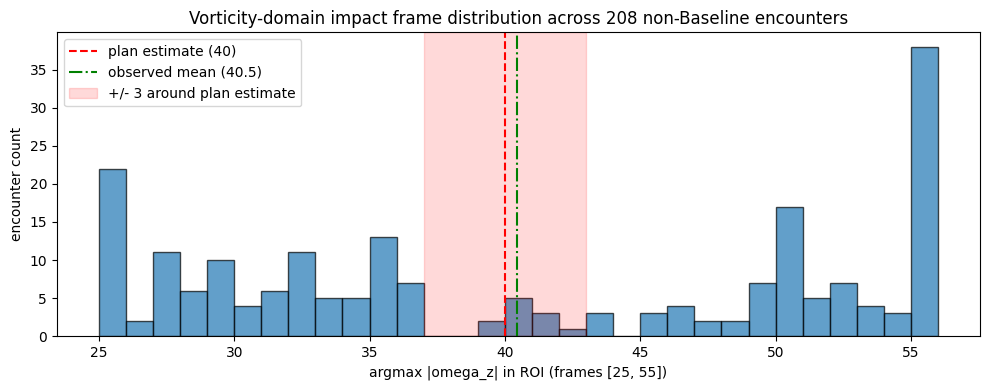


all encounters in window [25, 55]: True
mean within +/- 2 of 40:        True  (mean = 40.45)

Check 2A (vorticity-domain): PASS


In [3]:
with h5py.File(PREVENT_ROOT / 'data/raw/periodic/Baseline.h5', 'r') as raw:
    x = raw['/x'][:]
    y = raw['/y'][:]

roi_x = (x >= -0.5) & (x <= 1.5)
roi_y = (y >= -0.3) & (y <= 0.3)
print(f'ROI: x[{int(roi_x.sum())} cells] in [{x[roi_x].min():.3f}, {x[roi_x].max():.3f}], '
      f'y[{int(roi_y.sum())} cells] in [{y[roi_y].min():.3f}, {y[roi_y].max():.3f}]')

f0, f1 = WINDOW
omega_argmax = []
omega_per_case = {}
for c in inv['cases']:
    if c['case_id'] == 'Baseline':
        continue
    case_dir = CACHE / c['case_id']
    omega_per_case[c['case_id']] = []
    for enc in sorted(case_dir.glob('encounter_*.h5')):
        with h5py.File(enc, 'r') as g:
            omz = g['omega_z'][f0:f1 + 1]
        omz_roi = omz[:, roi_x, :][:, :, roi_y]
        max_per_frame = np.abs(omz_roi).reshape(omz_roi.shape[0], -1).max(axis=1)
        argmax_frame = f0 + int(np.argmax(max_per_frame))
        omega_argmax.append(argmax_frame)
        omega_per_case[c['case_id']].append(argmax_frame)

omega_argmax = np.array(omega_argmax)
print()
print(f'{len(omega_argmax)} encounters analyzed (Baseline excluded)')
print(f'distribution: min={omega_argmax.min()}, max={omega_argmax.max()}, '
      f'mean={omega_argmax.mean():.2f}, median={int(np.median(omega_argmax))}')
print(f'mode (most common frame): {int(np.bincount(omega_argmax).argmax())}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(omega_argmax, bins=range(f0, f1 + 2), edgecolor='black', alpha=0.7)
ax.axvline(IMPACT, color='red', linestyle='--', label=f'plan estimate ({IMPACT})')
ax.axvline(omega_argmax.mean(), color='green', linestyle='-.', label=f'observed mean ({omega_argmax.mean():.1f})')
ax.axvspan(IMPACT - 3, IMPACT + 3, alpha=0.15, color='red', label='+/- 3 around plan estimate')
ax.set_xlabel(f'argmax |omega_z| in ROI (frames [{f0}, {f1}])')
ax.set_ylabel('encounter count')
ax.set_title(f'Vorticity-domain impact frame distribution across {len(omega_argmax)} non-Baseline encounters')
ax.legend()
plt.tight_layout()
plt.show()

all_in_window = bool(np.all((omega_argmax >= f0) & (omega_argmax <= f1)))
mean_close = abs(omega_argmax.mean() - IMPACT) <= 2.0
print()
print(f'all encounters in window [{f0}, {f1}]: {all_in_window}')
print(f'mean within +/- 2 of {IMPACT}:        {mean_close}  (mean = {omega_argmax.mean():.2f})')
assert all_in_window, 'some encounters have argmax outside the impact window'
assert mean_close, f'mean argmax {omega_argmax.mean():.2f} is more than 2 from frame {IMPACT}'
print()
print('Check 2A (vorticity-domain): PASS')

## Check 2B - Force-domain impact frame

For each non-Baseline encounter, compute `argmax(|C_L - C_L_baseline|)` over `[25, 55]`. Baseline encounter `k mod 6` is the reference for any encounter k. This tracks the kinematic impact more directly than vorticity does.

Pass criterion: same as 2A (in window AND mean within +/- 2 of 40). Bonus expectation: distribution should be tighter / less bimodal than 2A.

Loaded 6 Baseline encounters as references.

208 encounters analyzed
distribution: min=25, max=55, mean=38.45, median=37, std=8.50
mode: 37


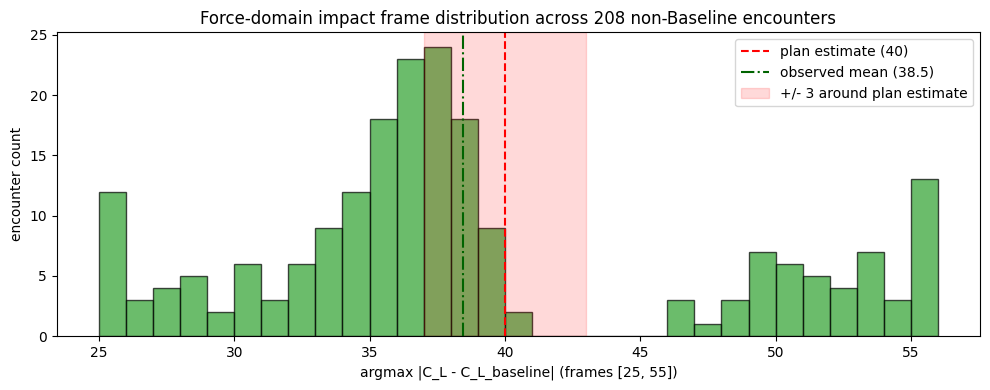


all encounters in window [25, 55]: True
mean within +/- 2 of 40:        True  (mean = 38.45)
within +/- 3 of 40: 53 / 208 (25.5%)

Check 2B (force-domain): PASS


In [4]:
baseline_cl = {}
for enc in sorted((CACHE / 'Baseline').glob('encounter_*.h5')):
    k = int(enc.stem.split('_')[1])
    with h5py.File(enc, 'r') as g:
        baseline_cl[k] = g['C_L'][:]
n_baseline_enc = len(baseline_cl)
print(f'Loaded {n_baseline_enc} Baseline encounters as references.')

force_argmax = []
force_per_case = {}
for c in inv['cases']:
    if c['case_id'] == 'Baseline':
        continue
    case_dir = CACHE / c['case_id']
    force_per_case[c['case_id']] = []
    for enc in sorted(case_dir.glob('encounter_*.h5')):
        k = int(enc.stem.split('_')[1])
        with h5py.File(enc, 'r') as g:
            cl = g['C_L'][:]
        diff = cl - baseline_cl[k % n_baseline_enc]
        argmax_frame = f0 + int(np.argmax(np.abs(diff[f0:f1 + 1])))
        force_argmax.append(argmax_frame)
        force_per_case[c['case_id']].append(argmax_frame)

force_argmax = np.array(force_argmax)
print()
print(f'{len(force_argmax)} encounters analyzed')
print(f'distribution: min={force_argmax.min()}, max={force_argmax.max()}, '
      f'mean={force_argmax.mean():.2f}, median={int(np.median(force_argmax))}, '
      f'std={force_argmax.std():.2f}')
print(f'mode: {int(np.bincount(force_argmax).argmax())}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(force_argmax, bins=range(f0, f1 + 2), edgecolor='black', alpha=0.7, color='C2')
ax.axvline(IMPACT, color='red', linestyle='--', label=f'plan estimate ({IMPACT})')
ax.axvline(force_argmax.mean(), color='darkgreen', linestyle='-.', label=f'observed mean ({force_argmax.mean():.1f})')
ax.axvspan(IMPACT - 3, IMPACT + 3, alpha=0.15, color='red', label='+/- 3 around plan estimate')
ax.set_xlabel(f'argmax |C_L - C_L_baseline| (frames [{f0}, {f1}])')
ax.set_ylabel('encounter count')
ax.set_title(f'Force-domain impact frame distribution across {len(force_argmax)} non-Baseline encounters')
ax.legend()
plt.tight_layout()
plt.show()

all_in_window = bool(np.all((force_argmax >= f0) & (force_argmax <= f1)))
mean_close = abs(force_argmax.mean() - IMPACT) <= 2.0
n_within3 = int(np.sum(np.abs(force_argmax - IMPACT) <= 3))
print()
print(f'all encounters in window [{f0}, {f1}]: {all_in_window}')
print(f'mean within +/- 2 of {IMPACT}:        {mean_close}  (mean = {force_argmax.mean():.2f})')
print(f'within +/- 3 of {IMPACT}: {n_within3} / {len(force_argmax)} ({100 * n_within3 / len(force_argmax):.1f}%)')
assert all_in_window
assert mean_close
print()
print('Check 2B (force-domain): PASS')

## Check 3 - Probe + force sanity

Side-by-side Baseline vs `Gust_007` (G=+4.0, strong LE impact, first encounter). Expectations:

- **Baseline forces:** low-amplitude periodic shedding signature in CL/CD; no impact spike.
- **Gust_007 forces:** large CL excursion peaking at frame ~51 (validated during Step 0).
- **Baseline LE probe:** shedding-frequency oscillation only.
- **Gust_007 LE probe:** sharp pressure deviation near impact frame.

LE probe idx: 11,  (x,y) = (-0.0001, +0.0000)
TE probe idx: 107,  (x,y) = (+1.0001, +0.0000)


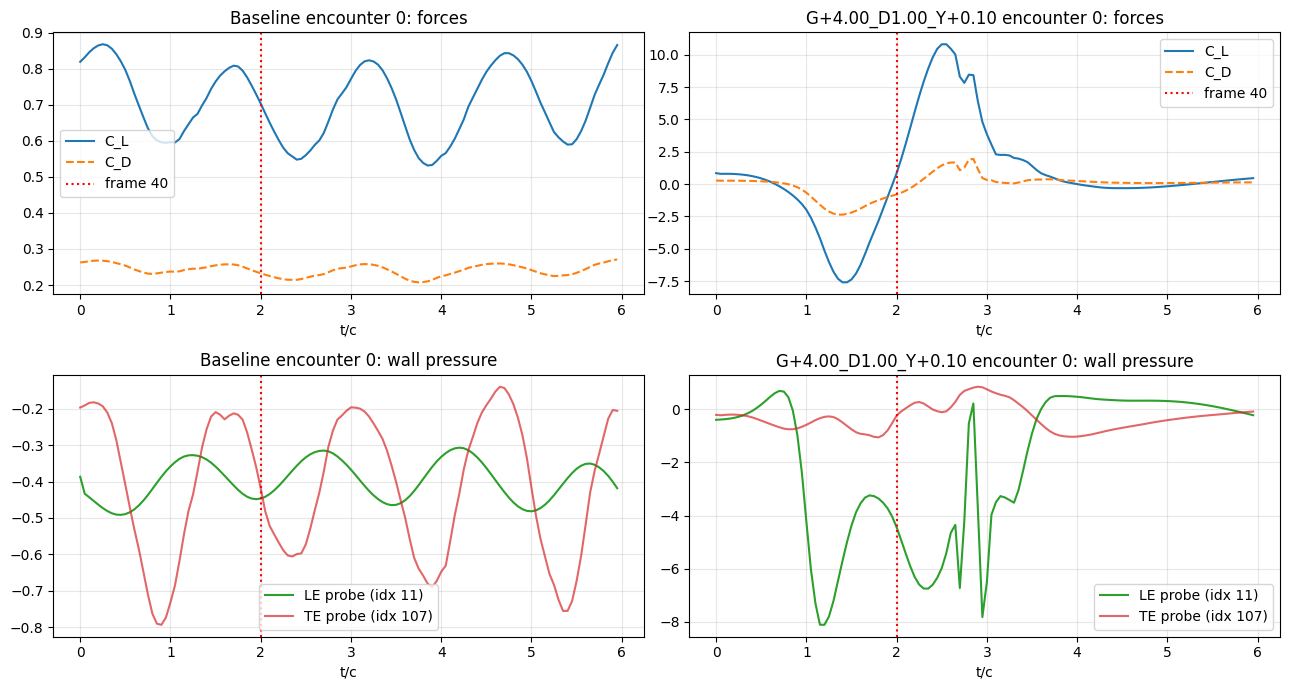

In [5]:
with h5py.File(PREVENT_ROOT / 'data/raw/periodic/Baseline.h5', 'r') as raw:
    sxyz = raw['/sensors/xyz'][:]
n_surf = config['sensors']['n_surface_points']
n_z = config['sensors']['n_z_stations']
sxyz_per_surface = sxyz.reshape(n_surf, n_z, 3)[:, 0, :]
le_idx = int(np.argmin(sxyz_per_surface[:, 0]))
te_idx = int(np.argmax(sxyz_per_surface[:, 0]))
print(f'LE probe idx: {le_idx},  (x,y) = ({sxyz_per_surface[le_idx, 0]:+.4f}, {sxyz_per_surface[le_idx, 1]:+.4f})')
print(f'TE probe idx: {te_idx},  (x,y) = ({sxyz_per_surface[te_idx, 0]:+.4f}, {sxyz_per_surface[te_idx, 1]:+.4f})')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
cases_to_plot = [('Baseline', 0), ('G+4.00_D1.00_Y+0.10', 0)]
t_axis = np.arange(N_FRAMES) * config['encounter']['dt_tc']
t_impact = IMPACT * config['encounter']['dt_tc']

for col, (cid, k) in enumerate(cases_to_plot):
    with h5py.File(CACHE / cid / f'encounter_{k:02d}.h5', 'r') as g:
        cl = g['C_L'][:]
        cd = g['C_D'][:]
        p_wall = g['p_wall'][:]
    axes[0, col].plot(t_axis, cl, label='C_L', color='C0')
    axes[0, col].plot(t_axis, cd, label='C_D', linestyle='--', color='C1')
    axes[0, col].axvline(t_impact, color='red', linestyle=':', label=f'frame {IMPACT}')
    axes[0, col].set_title(f'{cid} encounter {k}: forces')
    axes[0, col].set_xlabel('t/c')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(t_axis, p_wall[:, le_idx], label=f'LE probe (idx {le_idx})', color='C2')
    axes[1, col].plot(t_axis, p_wall[:, te_idx], label=f'TE probe (idx {te_idx})', color='C3', alpha=0.7)
    axes[1, col].axvline(t_impact, color='red', linestyle=':')
    axes[1, col].set_title(f'{cid} encounter {k}: wall pressure')
    axes[1, col].set_xlabel('t/c')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

If all checks pass, partition v1 is ready for training.

Notes on the bimodal vorticity distribution: `argmax(|omega_z|)` is a kinematic-impact proxy only when the impacting vortex itself is the strongest vorticity in the ROI. For strong gusts the vortex peaks pre-impact (frames ~25-32); for weak gusts the post-impact LE separation produces stronger vorticity (frames ~50-55). The mean and the force-domain argmax both stay near frame 40, which is the kinematic centroid-at-LE crossing time.

Next: smoke-test `src/data/episode_dataset.py` and move to JEPA training.